# Regressão Softmax com dados do MNIST utilizando gradiente descendente estocástico por minibatches

O objetivo deste notebook é ilustrar
- o uso do gradiente estocástico por mini-batchs
- utilizando as classes Dataset e DataLoater.

A apresentação da perda nos gráficos é um pouco diferente da usual, mostrando a perda de cada um dos vários minibatches dentro de cada época, de forma que as épocas são apresentadas com valores fracionários.

## Importação das bibliotecas

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.autograd import Variable
from torch.utils.data import DataLoader

import torchvision
from torchvision.datasets import MNIST

## Dataset e dataloader

### Definição do tamanho do minibatch

In [ ]:
batch_size = 100

### Carregamento, criação dataset e do dataloader

In [ ]:
dataset_dir = 'MNIST/'

# Load the full MNIST training dataset
full_train_dataset = MNIST(dataset_dir, train=True, download=True,
                      transform=torchvision.transforms.ToTensor())

# Define the split ratio (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Split the dataset
dataset_train, dataset_val = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

# Create DataLoaders for training and validation
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False) # No need to shuffle validation data

print(f'Número total de amostras de treinamento original: {len(full_train_dataset)}')
print(f'Número de amostras de treinamento: {len(dataset_train)}')
print(f'Número de amostras de validação: {len(dataset_val)}')
print('Número de minibatches de treinamento:', len(loader_train))
print('Número de minibatches de validação:', len(loader_val))

x_train_sample, y_train_sample = next(iter(loader_train))
print("\nDimensões dos dados de um minibatch de treinamento:", x_train_sample.size())
print("Valores mínimo e máximo dos pixels: ", torch.min(x_train_sample), torch.max(x_train_sample))
print("Tipo dos dados das imagens:         ", type(x_train_sample))
print("Tipo das classes das imagens:       ", type(y_train_sample))

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 473kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.61MB/s]

Número total de amostras de treinamento original: 60000
Número de amostras de treinamento: 48000
Número de amostras de validação: 12000
Número de minibatches de treinamento: 480
Número de minibatches de validação: 120

Dimensões dos dados de um minibatch de treinamento: torch.Size([100, 1, 28, 28])
Valores mínimo e máximo dos pixels:  tensor(0.) tensor(1.)
Tipo dos dados das imagens:          <class 'torch.Tensor'>
Tipo das classes das imagens:        <class 'torch.Tensor'>


### Usando todas as amostras do MNIST

Neste exemplo utilizaremos todas as amostras de treinamento.

In [ ]:
# The original `total_samples` was for the full training set. Now we have a split.
n_batches_train = len(loader_train)
n_batches_val = len(loader_val)
total_train_samples = len(dataset_train)
total_val_samples = len(dataset_val)

print(f'Número de minibatches de treinamento: {n_batches_train}')
print(f'Número de minibatches de validação: {n_batches_val}')
print(f'Total de amostras de treinamento: {total_train_samples}')
print(f'Total de amostras de validação: {total_val_samples}')

Número de minibatches de treinamento: 480
Número de minibatches de validação: 120
Total de amostras de treinamento: 48000
Total de amostras de validação: 12000


## Modelo

In [ ]:
model = torch.nn.Linear(28*28, 10)

In [ ]:
x = torch.ones(28*28).reshape(1, 784)
print(x.shape)
predict = model(x)
predict

torch.Size([1, 784])


tensor([[-0.7438,  0.5040,  0.5778, -0.1447,  0.6143, -0.6016, -0.7672, -0.0751,
         -0.0779, -0.3053]], grad_fn=<AddmmBackward0>)

In [ ]:
model(dataset_train[0][0].view(-1,784))

tensor([[-0.0516, -0.0499,  0.0182, -0.3547, -0.0093, -0.1295, -0.1781,  0.0772,
         -0.1591,  0.0084]], grad_fn=<AddmmBackward0>)

## Treinamento

Durante o treinamento, acompanharemos a perda e a acurácia para os conjuntos de treinamento e validação em cada época.

### Inicialização dos parâmetros

In [ ]:
n_epochs = 10
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos parâmetros

In [ ]:
train_losses_per_epoch = []
val_losses_per_epoch = []
train_accuracies_per_epoch = []
val_accuracies_per_epoch = []

for epoch in range(n_epochs):
    # Training phase
    model.train() # Set model to training mode
    correct_train = 0
    total_train = 0
    running_train_loss = 0.0

    for i, (x_train, y_train) in enumerate(loader_train):
        inputs = Variable(x_train.view(-1, 28 * 28))
        labels = Variable(y_train)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_train_loss / len(loader_train)
    train_accuracy = correct_train / total_train
    train_losses_per_epoch.append(avg_train_loss)
    train_accuracies_per_epoch.append(train_accuracy)

    # Validation phase
    model.eval() # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    running_val_loss = 0.0

    with torch.no_grad(): # Disable gradient calculations during validation
        for x_val, y_val in loader_val:
            inputs_val = Variable(x_val.view(-1, 28 * 28))
            labels_val = Variable(y_val)

            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)

            running_val_loss += loss_val.item()
            _, predicted_val = torch.max(outputs_val.data, 1)
            total_val += labels_val.size(0)
            correct_val += (predicted_val == labels_val).sum().item()

    avg_val_loss = running_val_loss / len(loader_val)
    val_accuracy = correct_val / total_val
    val_losses_per_epoch.append(avg_val_loss)
    val_accuracies_per_epoch.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{n_epochs}], ' \
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, ' \
          f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}')

Epoch [1/10], Train Loss: 0.4059, Train Acc: 0.8844, Val Loss: 0.3398, Val Acc: 0.9028
Epoch [2/10], Train Loss: 0.3071, Train Acc: 0.9134, Val Loss: 0.3252, Val Acc: 0.9106
Epoch [3/10], Train Loss: 0.2907, Train Acc: 0.9179, Val Loss: 0.3123, Val Acc: 0.9143
Epoch [4/10], Train Loss: 0.2817, Train Acc: 0.9201, Val Loss: 0.3164, Val Acc: 0.9142
Epoch [5/10], Train Loss: 0.2762, Train Acc: 0.9222, Val Loss: 0.3150, Val Acc: 0.9134
Epoch [6/10], Train Loss: 0.2715, Train Acc: 0.9241, Val Loss: 0.3113, Val Acc: 0.9147
Epoch [7/10], Train Loss: 0.2681, Train Acc: 0.9251, Val Loss: 0.3090, Val Acc: 0.9182
Epoch [8/10], Train Loss: 0.2651, Train Acc: 0.9253, Val Loss: 0.3129, Val Acc: 0.9139
Epoch [9/10], Train Loss: 0.2627, Train Acc: 0.9266, Val Loss: 0.3110, Val Acc: 0.9150
Epoch [10/10], Train Loss: 0.2612, Train Acc: 0.9272, Val Loss: 0.3088, Val Acc: 0.9182


In [ ]:
print('--- Treinamento Finalizado ---')
print(f'Última perda de treinamento: {train_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de treinamento: {train_accuracies_per_epoch[-1]:.4f}')
print(f'Última perda de validação: {val_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de validação: {val_accuracies_per_epoch[-1]:.4f}')

--- Treinamento Finalizado ---
Última perda de treinamento: 0.2612
Última acurácia de treinamento: 0.9272
Última perda de validação: 0.3088
Última acurácia de validação: 0.9182


### Visualizando a evolução da perda e acurácia

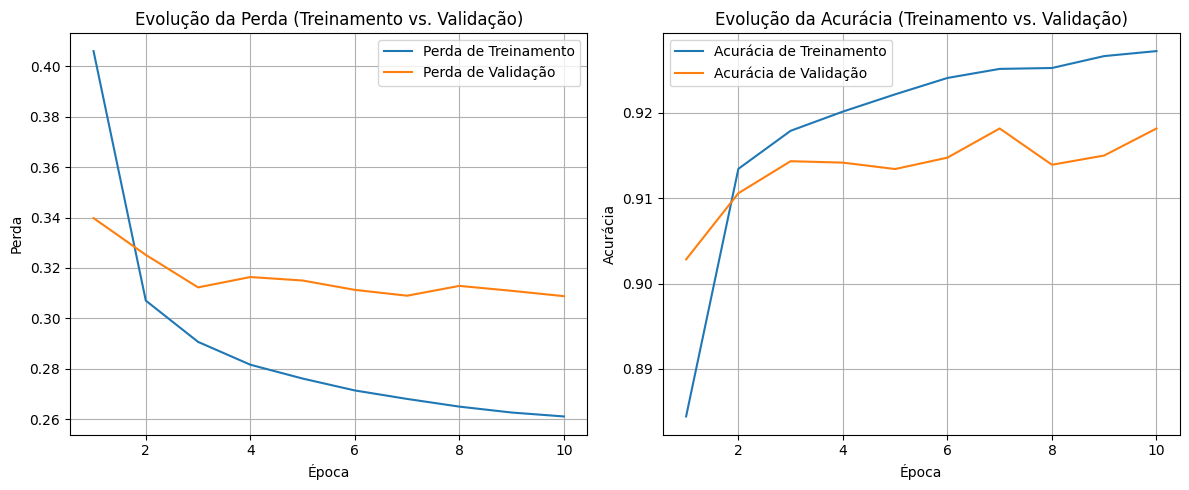

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs + 1), train_losses_per_epoch, label='Perda de Treinamento')
plt.plot(range(1, n_epochs + 1), val_losses_per_epoch, label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('Evolução da Perda (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs + 1), train_accuracies_per_epoch, label='Acurácia de Treinamento')
plt.plot(range(1, n_epochs + 1), val_accuracies_per_epoch, label='Acurácia de Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Evolução da Acurácia (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Observações sobre os gráficos

Estes gráficos mostram a perda e a acurácia calculadas ao final de cada época para os conjuntos de treinamento e validação. Idealmente, a perda de treinamento e validação deve diminuir, e a acurácia deve aumentar, com as curvas de validação seguindo de perto as de treinamento. Divergências significativas podem indicar overfitting ou underfitting.

# Atividades

## Perguntas

1. Qual é o tamanho do mini-batch?
      
        R: 100
2. Em uma época, quantos mini-batches existem?
      
        R: 48.000/10 = 480 mini-batches.
      
3. Qual é a definição de época?
      
        R: Época é uma volta completa pelo dataset de treinamento, o número de épocas define quantas vezes esse processo será realizado, permitindo, a cada vez, que o modelo refine o aprendizado.

## Exercícios


1. Coloque um print no final de cada minibatch, no mesmo estilo do print do final de época, no seguinte estilo:
    - Época: 1/4, batch: 600
2. Altere o tamanho de minibatch (batch_size) algumas vezes, refaça o treinamento, e compare no gráfico abaixo a queda da perda para cada tamanho de minibatch.

In [ ]:
1#
train_losses_per_epoch = []
val_losses_per_epoch = []
train_accuracies_per_epoch = []
val_accuracies_per_epoch = []

for epoch in range(n_epochs):
    # Training phase
    model.train() # Set model to training mode
    correct_train = 0
    total_train = 0
    running_train_loss = 0.0

    for i, (x_train, y_train) in enumerate(loader_train):
        inputs = Variable(x_train.view(-1, 28 * 28))
        labels = Variable(y_train)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        #####
        print(f'Época: {epoch+1}/{n_epochs}, batch: {(i+1)*batch_size}')
        #####
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_train_loss / len(loader_train)
    train_accuracy = correct_train / total_train
    train_losses_per_epoch.append(avg_train_loss)
    train_accuracies_per_epoch.append(train_accuracy)

    # Validation phase
    model.eval() # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    running_val_loss = 0.0

    with torch.no_grad(): # Disable gradient calculations during validation
        for x_val, y_val in loader_val:
            inputs_val = Variable(x_val.view(-1, 28 * 28))
            labels_val = Variable(y_val)

            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)

            running_val_loss += loss_val.item()
            _, predicted_val = torch.max(outputs_val.data, 1)
            total_val += labels_val.size(0)
            correct_val += (predicted_val == labels_val).sum().item()

    avg_val_loss = running_val_loss / len(loader_val)
    val_accuracy = correct_val / total_val
    val_losses_per_epoch.append(avg_val_loss)
    val_accuracies_per_epoch.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{n_epochs}], ' \
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, ' \
          f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}')

Época: 1/5, batch: 500
Época: 1/5, batch: 1000
Época: 1/5, batch: 1500
Época: 1/5, batch: 2000
Época: 1/5, batch: 2500
Época: 1/5, batch: 3000
Época: 1/5, batch: 3500
Época: 1/5, batch: 4000
Época: 1/5, batch: 4500
Época: 1/5, batch: 5000
Época: 1/5, batch: 5500
Época: 1/5, batch: 6000
Época: 1/5, batch: 6500
Época: 1/5, batch: 7000
Época: 1/5, batch: 7500
Época: 1/5, batch: 8000
Época: 1/5, batch: 8500
Época: 1/5, batch: 9000
Época: 1/5, batch: 9500
Época: 1/5, batch: 10000
Época: 1/5, batch: 10500
Época: 1/5, batch: 11000
Época: 1/5, batch: 11500
Época: 1/5, batch: 12000
Época: 1/5, batch: 12500
Época: 1/5, batch: 13000
Época: 1/5, batch: 13500
Época: 1/5, batch: 14000
Época: 1/5, batch: 14500
Época: 1/5, batch: 15000
Época: 1/5, batch: 15500
Época: 1/5, batch: 16000
Época: 1/5, batch: 16500
Época: 1/5, batch: 17000
Época: 1/5, batch: 17500
Época: 1/5, batch: 18000
Época: 1/5, batch: 18500
Época: 1/5, batch: 19000
Época: 1/5, batch: 19500
Época: 1/5, batch: 20000
Época: 1/5, batch: 2


=== Treinando com batch_size = 10 ===
  Época 1/5 - Perda: 0.5537
  Época 2/5 - Perda: 0.4960
  Época 3/5 - Perda: 0.4790
  Época 4/5 - Perda: 0.4719
  Época 5/5 - Perda: 0.4575

=== Treinando com batch_size = 50 ===
  Época 1/5 - Perda: 0.3843
  Época 2/5 - Perda: 0.3121
  Época 3/5 - Perda: 0.2988
  Época 4/5 - Perda: 0.2907
  Época 5/5 - Perda: 0.2855

=== Treinando com batch_size = 100 ===
  Época 1/5 - Perda: 0.4067
  Época 2/5 - Perda: 0.3102
  Época 3/5 - Perda: 0.2942
  Época 4/5 - Perda: 0.2851
  Época 5/5 - Perda: 0.2790

=== Treinando com batch_size = 500 ===
  Época 1/5 - Perda: 0.5796
  Época 2/5 - Perda: 0.3712
  Época 3/5 - Perda: 0.3401
  Época 4/5 - Perda: 0.3235
  Época 5/5 - Perda: 0.3127


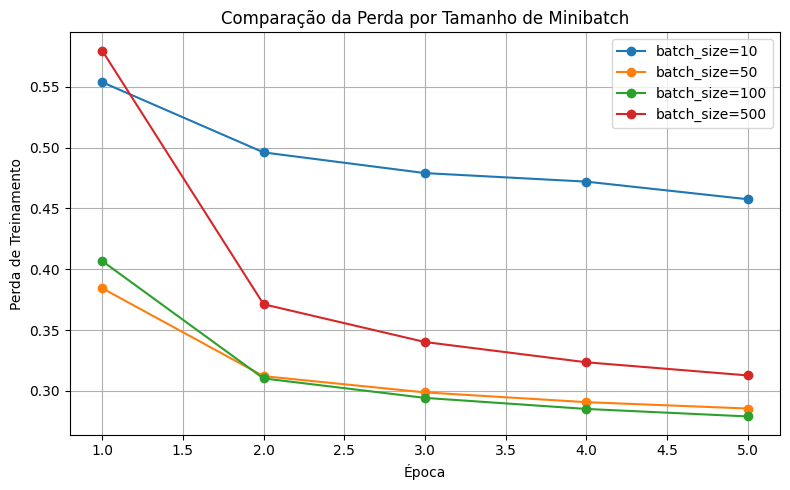

In [ ]:
# Exercício 2: Comparação da perda para diferentes tamanhos de minibatch

batch_sizes = [10, 50, 100, 500]
n_epochs = 5
learningRate = 0.5
dataset_dir = 'MNIST/'

all_train_losses = {}

for batch_size in batch_sizes:
    print(f'\n=== Treinando com batch_size = {batch_size} ===')

    full_train_dataset = MNIST(dataset_dir, train=True, download=True,
                          transform=torchvision.transforms.ToTensor())
    train_size = int(0.8 * len(full_train_dataset))
    val_size = len(full_train_dataset) - train_size
    dataset_train, dataset_val = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])
    loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

    model = torch.nn.Linear(28*28, 10)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

    train_losses = []

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0

        for x_train, y_train in loader_train:
            inputs = x_train.view(-1, 28 * 28)
            labels = y_train

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(loader_train)
        train_losses.append(avg_loss)
        print(f'  Época {epoch+1}/{n_epochs} - Perda: {avg_loss:.4f}')

    all_train_losses[batch_size] = train_losses

# Gráfico comparativo
plt.figure(figsize=(8, 5))
for batch_size, losses in all_train_losses.items():
    plt.plot(range(1, n_epochs + 1), losses, marker='o', label=f'batch_size={batch_size}')

plt.xlabel('Época')
plt.ylabel('Perda de Treinamento')
plt.title('Comparação da Perda por Tamanho de Minibatch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Conclusões sobre os experimentos deste notebook


Com base na comparação da perda por conta do tamanho do minibatch foi possível perceber comportamentos diferentes conforme a variação de tamanho do minibatch.

O menor batch (10), tem o pior desempenho. Ele inicia com uma perda alta e apresenta uma decréscimo muito pequeno, o que indica que o excesso de ruído prejudica a convergência com a taxa de aprendizado.

O maior batch (500) começa com uma perda alta, mas apresenta uma queda acentuada já nas primeiras épocas. Mostra-se melhor que o batch 10, mas ainda não é o ideal.

Os batches nédios aptesentam o melhor desempenho, convergem mais rápido e melhor. Partem de perdas inciais mais baixas e ainda apresentam decrescimos, apresentando uma maior eficiência.